# Импорты

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Задание 1

## Входные данные

In [25]:
X = np.array([
    3.53,
    9.56,
    7.03,
    9.18,
    7.45,
    5.59,
    6.85,
    11.3,
    7.90,
    6.00,
    6.68,
    5.66,
    8.64,

    8.87,
    4.58,
    11.3,
    5.02,
    4.33,
    9.31,
    10.3,
    5.99,
    6.98,
    5.23,
    8.75,
    7.73,
    9.16
])

## Интервальный вариационный ряд

In [26]:
X_min = min(X)
X_max = max(X)
R = X_max - X_min
N = int(1 + 3.322 * np.log10(len(X)))
delta = R / N

bins = [X_min + i * delta for i in range(N + 1)]
bins[-1] = X_max

counts, _ = np.histogram(X, bins=bins)
intervals_labels = []
for i in range(N):
    if i == N - 1:
        intervals_labels.append(f"[{bins[i]}; {bins[i + 1]}]")
    else:
        intervals_labels.append(f"[{bins[i]}; {bins[i + 1]})")

df_group = pd.DataFrame(
    {
        "Интервал №": range(1, N + 1),
        "Границы интервала": intervals_labels,
        "Частота, n_i": counts,
        "Частность, w_i": counts / len(X),
        "Накопленные частоты": [np.sum(counts[:i + 1] / len(X)) for i in range(N)]
    }
)
df_group

,Интервал №,Границы интервала,"Частота, n_i","Частность, w_i",Накопленные частоты
0,1,[3.53; 5.084),4,0.153846,0.153846
1,2,[5.084; 6.638),5,0.192308,0.346154
2,3,[6.638; 8.192),7,0.269231,0.615385
3,4,[8.192; 9.746),7,0.269231,0.884615
4,5,[9.746; 11.3],3,0.115385,1.000000


## Функция распределения

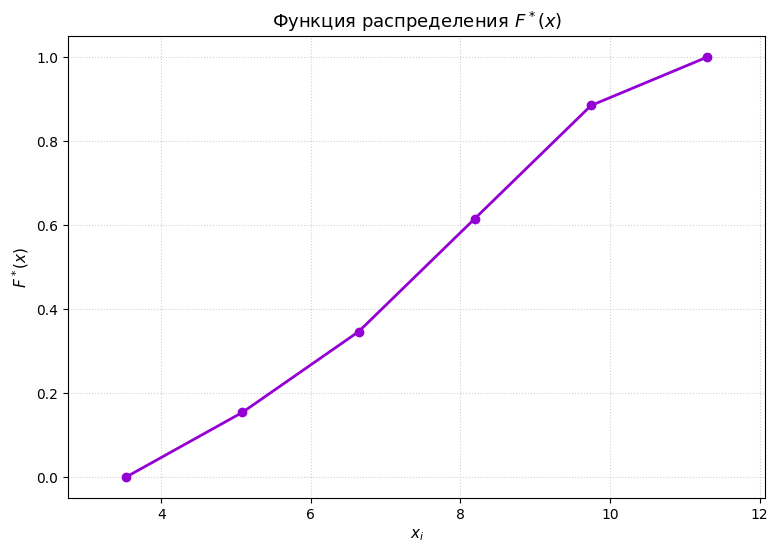

In [27]:
w_k = counts / len(X)
F_cum = np.insert(np.cumsum(w_k), 0, 0.0)

plt.figure(figsize=(9, 6))

plt.plot(bins, F_cum, color="darkviolet", marker="o", linewidth=2, label="$F^*(x)$")

plt.title("Функция распределения $F^*(x)$", fontsize=13)
plt.xlabel("$x_i$", fontsize=11)
plt.ylabel("$F^*(x)$", fontsize=11)

plt.xlim(bins[0] - delta / 2, bins[-1] + delta / 2)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

# Задание 2

## Входные данные

In [28]:
X = [
    5,
    3,
    4,
    4,
    0,
    1,
    5,
    1,
    2,
    2,
    1,
    4,
    2,
    2,
    0,

    3,
    2,
    1,
    2,
    4,
    2,
    0,
    2,
    2,
    0,
    4,
    0,
    1,
    5,
    1
]

## Дискретный вариационный ряд

In [29]:
variants, counts = np.unique(X, return_counts=True)

df_discrete = pd.DataFrame(
    {
        "Варианта, x_i": variants,
        "Частота, n_i": counts,
        "Относительная частота, w_i": counts / len(X) ,
        "Накопленная частота": np.cumsum(counts),
    }
)
df_discrete

,"Варианта, x_i","Частота, n_i","Относительная частота, w_i",Накопленная частота
0,0,5,0.166667,5
1,1,6,0.200000,11
2,2,9,0.300000,20
3,3,2,0.066667,22
4,4,5,0.166667,27
5,5,3,0.100000,30


## Функция распределения

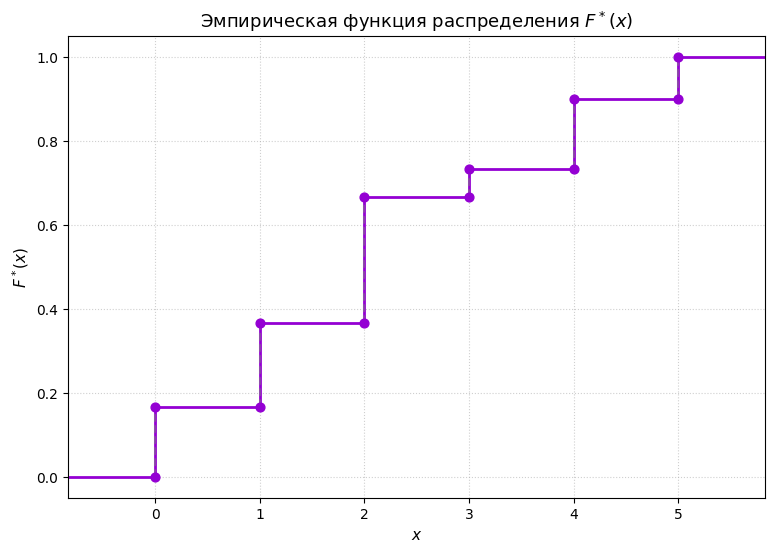

In [35]:
variants, counts = np.unique(X, return_counts=True)
w_i = counts / len(X)
F_cum = np.cumsum(w_i)

step = (max(variants) - min(variants)) / len(variants) if len(variants) > 1 else 1.0
X_plot = np.concatenate([[variants[0] - step], variants, [variants[-1] + step]])
F_plot = np.concatenate([[0.0], F_cum, [1.0]])

plt.figure(figsize=(9, 6))

plt.step(
    X_plot,
    F_plot,
    where="post",
    color="darkviolet",
    linewidth=2,
    label="$F^*(x)$",
)

plt.scatter(variants, F_cum, color="darkviolet", s=40, zorder=3)
plt.scatter(
    variants[1:],
    F_cum[:-1],
    color="darkviolet",
    edgecolors="darkviolet",
    s=40,
    zorder=3,
)
plt.scatter(
    variants[0],
    0.0,
    color="darkviolet",
    edgecolors="darkviolet",
    s=40,
    zorder=3,
)

for v, f_prev, f_curr in zip(variants, np.insert(F_cum[:-1], 0, 0.0), F_cum):
    plt.vlines(v, f_prev, f_curr, colors="gray", linestyles="dashed", alpha=0.5)

plt.title("Эмпирическая функция распределения $F^*(x)$", fontsize=13)
plt.xlabel("$x$", fontsize=11)
plt.ylabel("$F^*(x)$", fontsize=11)

plt.xlim(X_plot[0], X_plot[-1])
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()